# 2일차 3교시 실습 · 윤곽선과 객체 후보

강의자료 PDF의 6·11·12쪽을 보고 `____` 세 곳을 채웁니다. 압축을 전체 해제하고 위에서 아래로 실행합니다. 이미지와 마스크는 1교시와 동일한 영역입니다. 필요한 패키지는 OpenCV·NumPy·Matplotlib입니다.

`show_compare`는 제공 함수입니다. ROI는 잘라낸 관심 영역입니다. 사진의 모든 좌표는 제공한 ROI 이미지 기준이며, 격자 사례는 각 격자 기준입니다. 원본 전체 사진 좌표로 바꾸려면 y에150을 더합니다.


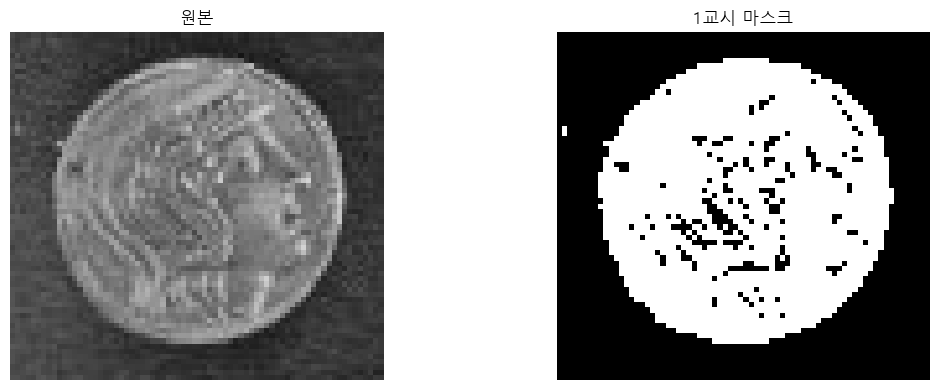

In [16]:
from pathlib import Path
import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
gray = cv2.imdecode(np.fromfile('images/gray.png', dtype=np.uint8), 0)
mask_raw = cv2.imdecode(np.fromfile('images/mask_raw.png', dtype=np.uint8), 0)
assert gray is not None and mask_raw is not None
assert gray.shape == mask_raw.shape and mask_raw.dtype == np.uint8
assert set(np.unique(mask_raw)).issubset({0, 255})
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
detail = (slice(78, 145), slice(10, 82))
zoom = (slice(12, 80), slice(8, 78))

def show_compare(images, titles, region=None):
    fig, axes = plt.subplots(1, len(images), figsize=(12, 4), squeeze=False)
    for ax, image, title in zip(axes[0], images, titles):
        shown = image if region is None else image[region]
        if shown.ndim == 3:
            shown = cv2.cvtColor(shown, cv2.COLOR_BGR2RGB)
        ax.imshow(shown, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_compare([gray, mask_raw], ['원본', '1교시 마스크'], detail)


## Erosion·Dilation 확인 · 강의자료 PDF 4~5쪽
두 연산은 동일한 원본 마스크에 독립적으로 적용합니다. Kernel은 사각형3×3, 반복 횟수는1입니다.


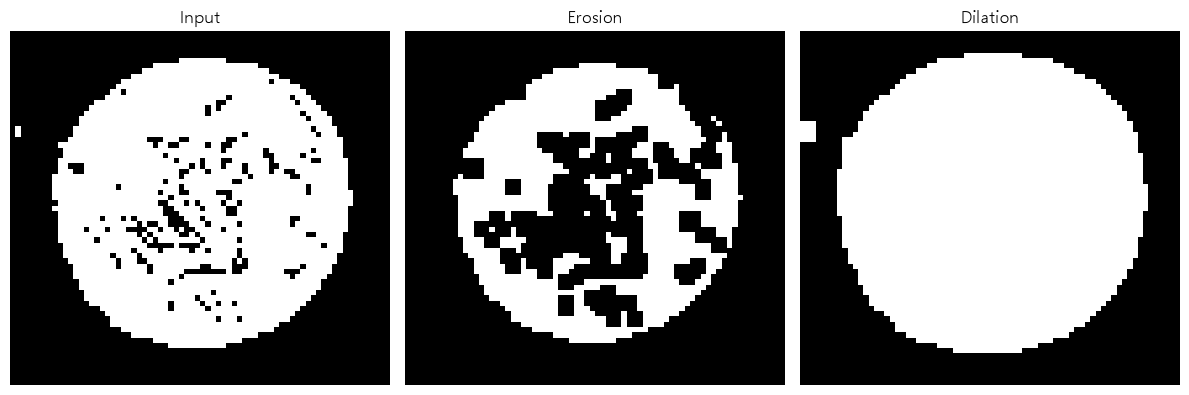

In [17]:
eroded = cv2.erode(mask_raw, kernel, iterations=1)
dilated = cv2.dilate(mask_raw, kernel, iterations=1)
show_compare([mask_raw, eroded, dilated], ['Input', 'Erosion', 'Dilation'], detail)

# 이 단계를 왜 하는 걸까...? 동전의 테두를 찾다보니까, 침식이라는 행위는 할 필요가 없는데 글씨같은 경우 침식해서 두껍게 만들면 보기 편하니까 그때 사용하는 경우가 많다.
# 팽창은 흰색기준으로 살펴보면 흰색이 늘어난 경우를 볼 수 있음. 

## A · Opening · 강의자료 PDF 6쪽
침식 후 팽창을 적용하는 연산 옵션 한 곳을 채웁니다.


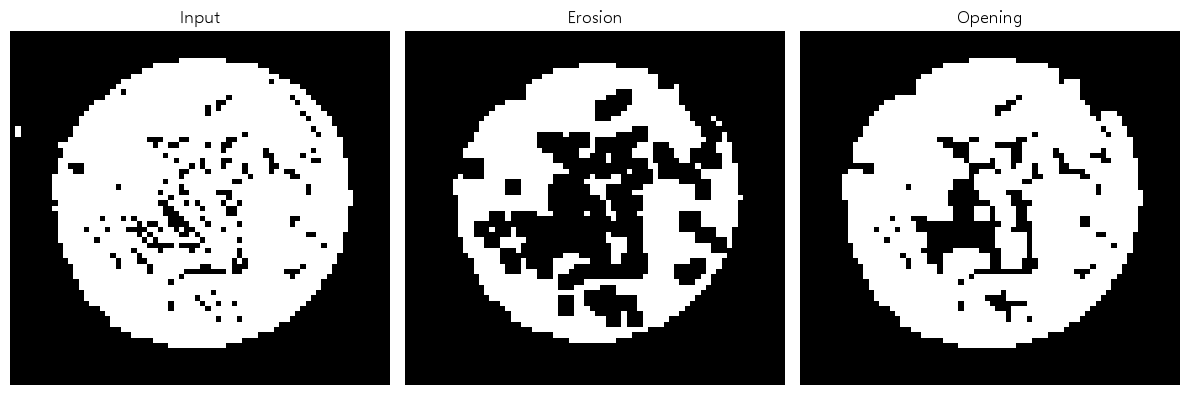

In [18]:
mask_open = cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN, kernel)
show_compare([mask_raw, eroded, mask_open], ['Input', 'Erosion', 'Opening'], detail)

# 기존에 있던 점같은게 더 윤곽이 더 뚜렷해질 수 있음.

## Closing과 Kernel 크기 · 강의자료 PDF 7~8쪽
Closing 비교는 원본 마스크에 독립 적용합니다. 크기 비교에서는 Opening을 사용하고, Kernel 크기만 바꿉니다.


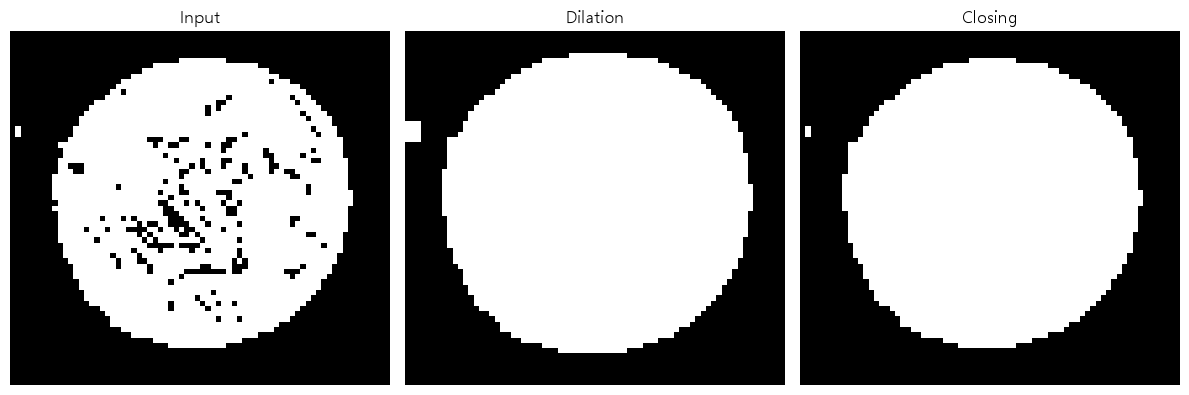

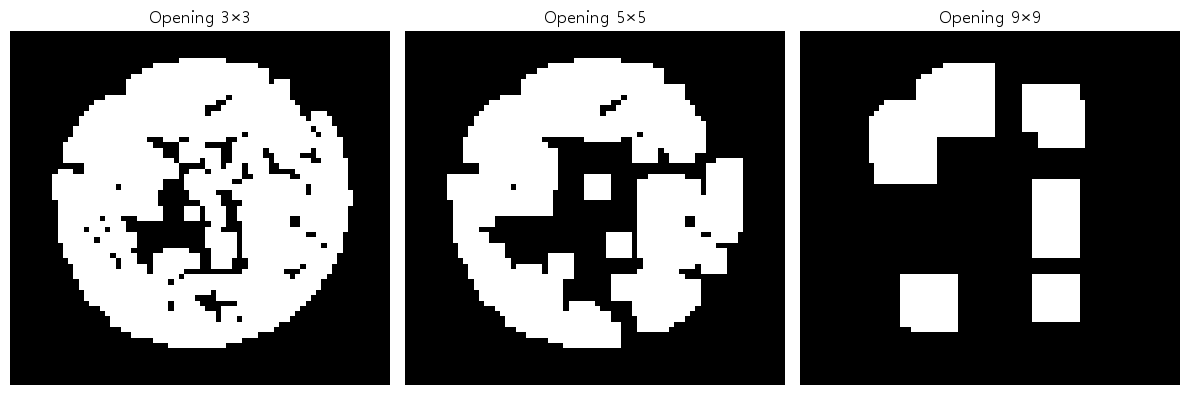

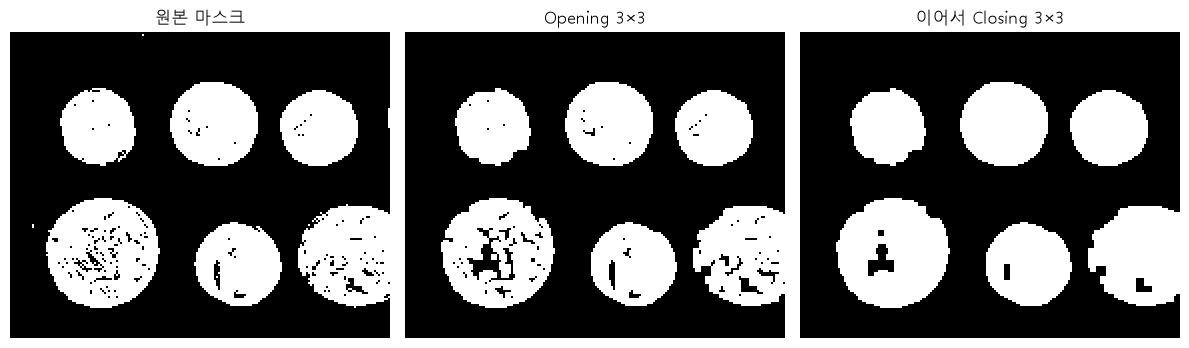

In [19]:
mask_close_demo = cv2.morphologyEx(mask_raw, cv2.MORPH_CLOSE, kernel)
show_compare([mask_raw, dilated, mask_close_demo], ['Input', 'Dilation', 'Closing'], detail)
opening_sizes = [cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN,
                  cv2.getStructuringElement(cv2.MORPH_RECT, (size, size)))
                 for size in (3, 5, 9)]
show_compare(opening_sizes, ['Opening 3×3', 'Opening 5×5', 'Opening 9×9'], detail)
mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel)
show_compare([mask_raw, mask_open, mask_clean], ['원본 마스크', 'Opening 3×3', '이어서 Closing 3×3'])

#확장되어서 동전의 원래 크기보다 더 커짐... 이걸 다시 축소시킬 필요가 있음.
# fig2 , fig3 참고.

## 외부 Contour와 내부 경계 · 강의자료 PDF 10쪽
같은 원본 마스크에서 검색 모드만 바꿉니다. 외부 윤곽선을 추출해도 마스크의 구멍은 그대로입니다.


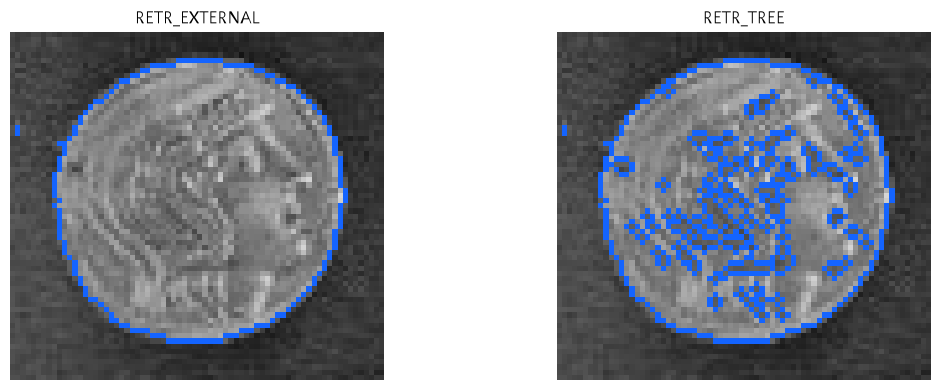

In [20]:
views = []
for mode in (cv2.RETR_EXTERNAL, cv2.RETR_TREE):
    demo_contours, _ = cv2.findContours(mask_raw, mode, cv2.CHAIN_APPROX_SIMPLE)
    view = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(view, demo_contours, -1, (255, 100, 20), 1)
    views.append(view)
show_compare(views, ['RETR_EXTERNAL', 'RETR_TREE'], detail)


## B · Contour 추출 · 강의자료 PDF 11쪽
함수 이름을 채웁니다. 후보 번호는 박스의 y좌표, x좌표 순으로 정렬해 부여합니다. 실제 물체의 종류를 판별한 결과는 아닙니다.


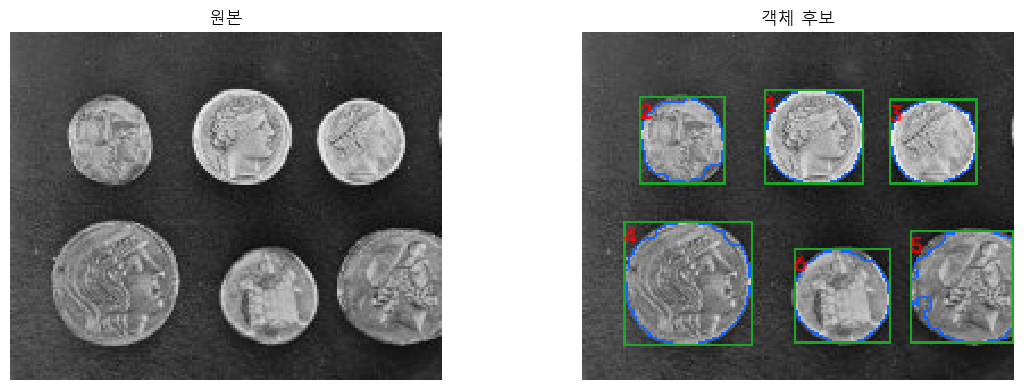

In [21]:
contours, hierarchy = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=lambda c: (cv2.boundingRect(c)[1], cv2.boundingRect(c)[0]))
assert contours, '윤곽선이 없습니다. 입력 마스크와 준비 셀을 확인하세요.'
view = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for candidate_id, contour in enumerate(contours, 1):
    x, y, w, h = cv2.boundingRect(contour)
    cv2.drawContours(view, [contour], -1, (255, 100, 20), 1)
    cv2.rectangle(view, (x, y), (x+w-1, y+h-1), (40, 165, 30), 1)
    cv2.putText(view, str(candidate_id), (x, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 0, 255), 1, cv2.LINE_AA)
show_compare([gray, view], ['원본', '객체 후보'])


## C · Contour 면적 · 강의자료 PDF 12쪽
면적 계산 함수 이름을 채웁니다. 제공된 사진에서 후보2를 설명 대상으로 지정합니다. 이 지정은 자동 동전 선별 규칙이 아닙니다.

둘레와 Bounding Box는 강의자료 PDF 14~15쪽의 완성 코드입니다. 면적 단위는pixel², 둘레 단위는pixel입니다.


In [25]:
assert len(contours) >= 2, '후보2를 확인할 수 없습니다. 원본 입력으로 다시 실행하세요.'
contour = contours[1]
area = cv2.contourArea(contour)
perimeter = cv2.arcLength(contour, True)
x, y, w, h = cv2.boundingRect(contour)
print(f'후보2 면적: {area:.1f} pixel²')
print(f'후보2 둘레: {perimeter:.2f} pixel')
print('후보2 박스 (x,y,w,h):', (x, y, w, h))


후보2 면적: 1043.5 pixel²
후보2 둘레: 128.33 pixel
후보2 박스 (x,y,w,h): (25, 28, 38, 39)


## 후보별 특징 기록·저장 · 강의자료 PDF 16쪽
전체 후보의 특징을CSV로, 표시 결과를PNG로 저장합니다. 영상 경계에 잘린 후보의 크기는 전체 물체 크기와 다를 수 있습니다.


In [26]:
rows = []
for candidate_id, contour in enumerate(contours, 1):
    x, y, w, h = cv2.boundingRect(contour)
    rows.append([candidate_id, cv2.contourArea(contour), cv2.arcLength(contour, True), x, y, w, h])
output_dir = Path('results')
output_dir.mkdir(exist_ok=True)
with (output_dir / 'candidate_features.csv').open('w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['candidate_id', 'area_pixel2', 'perimeter_pixel', 'x', 'y', 'w', 'h'])
    writer.writerows(rows)
for name, image in [('candidates', view), ('mask_clean', mask_clean)]:
    ok, encoded = cv2.imencode('.png', image)
    assert ok
    encoded.tofile(output_dir / f'{name}.png')
print('저장 위치:', output_dir.resolve())


저장 위치: C:\Users\User\Downloads\Lecture_notes\13. 딥러닝 기반 영상처리_1,2일차\Pratice\day2\session3\results


## 사례 · 면적과 흰 픽셀 수 · 강의자료 PDF 13쪽
설명용 단일 블록입니다. 검은 여백 안에3×3 전경을 배치합니다.


흰 픽셀 수: 9
Contour 면적: 4.0


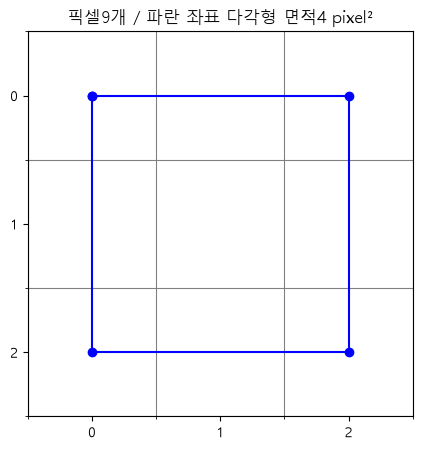

In [27]:
block = np.zeros((7, 7), np.uint8)
block[2:5, 2:5] = 255
block_contours, _ = cv2.findContours(block, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print('흰 픽셀 수:', cv2.countNonZero(block))
print('Contour 면적:', cv2.contourArea(block_contours[0]))
points = block_contours[0].reshape(-1, 2) - 2
closed_points = np.vstack([points, points[0]])
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(block[2:5, 2:5], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax.plot(closed_points[:, 0], closed_points[:, 1], 'bo-')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
ax.grid(which='minor', color='gray')
ax.set_title('픽셀9개 / 파란 좌표 다각형 면적4 pixel²')
plt.show()


## 사례 · 외곽 픽셀 중심 좌표의 중점과 Centroid · 강의자료 PDF 17쪽
설명용 비대칭 마스크입니다. 이 사례의 대표점은 외곽 픽셀 중심 좌표의 중점 `(x+(w−1)/2, y+(h−1)/2)`입니다. Centroid(영역의 무게중심)는 전경 픽셀 좌표의 평균으로 정의합니다. 이후 5~8교시의 검출·추적에서는 사각형 범위 중심 `(x+w/2, y+h/2)`를 대표 위치로 사용합니다. 두 정의는 각 축에서 0.5픽셀 차이가 있습니다.


외곽 픽셀 중심 좌표의 중점: (4.0, 4.0)
영역 중심: (2.96, 5.04)


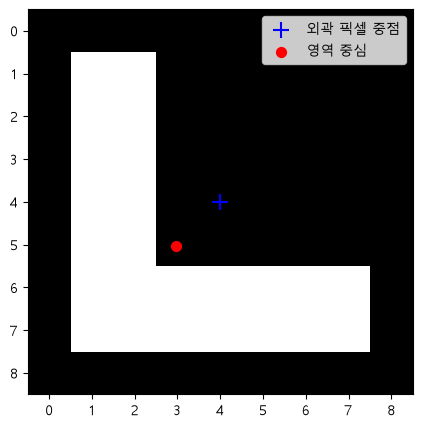

In [28]:
asymmetric = np.zeros((9, 9), np.uint8)
asymmetric[1:8, 1:3] = 255
asymmetric[6:8, 1:8] = 255
asymmetric_contours, _ = cv2.findContours(asymmetric, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
x, y, w, h = cv2.boundingRect(asymmetric_contours[0])
box_center = (x+(w-1)/2, y+(h-1)/2)
ys, xs = np.where(asymmetric > 0)
region_center = (xs.mean(), ys.mean())
print('외곽 픽셀 중심 좌표의 중점:', box_center)
print('영역 중심:', tuple(round(float(v), 2) for v in region_center))
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(asymmetric, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax.scatter(*box_center, color='blue', marker='+', s=140, label='외곽 픽셀 중점')
ax.scatter(*region_center, color='red', s=50, label='영역 중심')
ax.set_xticks(range(9)); ax.set_yticks(range(9)); ax.legend()
plt.show()
